In [2]:
import torch
print("PyTorch :", torch.__version__)
print("CUDA :", torch.cuda.is_available())
print("CUDA version :", torch.version.cuda)
print("GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "not available")

PyTorch : 2.14.0+cu126
CUDA : True
CUDA version : 12.6
GPU : NVIDIA GeForce RTX 3050 Laptop GPU


# 1. SETUP

In [3]:
import copy
import gc
import os
import random
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def seed_everything(seed) :
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 42
seed_everything(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cuda


# 2. CONFIG

In [4]:
SEEDS = [42, 43, 44] # default 42
RUN_TAG = "pilot"
DATA_DIR = Path("data/processed")
CHECKPOINT_DIR = Path("checkpoints") / RUN_TAG
REPORT_DIR = Path("reports") / RUN_TAG
FIG_DIR = REPORT_DIR / "figures"
METRICS_DIR = REPORT_DIR / "metrics"
for directory in (CHECKPOINT_DIR, FIG_DIR, METRICS_DIR) :
    directory.mkdir(parents=True, exist_ok=True)
assert DATA_DIR.is_dir(), f"Dataset terproses tidak ditemukan: {DATA_DIR}"

IMG_SIZE = (224, 224)
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
HIDDEN_DIM = 512
NUM_CLASSES = 4
STAGE_MAX_EPOCHS = 50
PATIENCE = 5
FINE_TUNE_LR_DIV = 10
BASE_CONFIG = {"optimizer": "Adam", "lr": 1e-4, "dropout": 0.5, "batch_size": 16}
GRID = {
    "optimizer": ["Adam", "AdamW"],
    "lr": [1e-3, 1e-4, 1e-5],
    "dropout": [0.2, 0.3, 0.4, 0.5],
    "batch_size": [16, 32],
}
CLASS_DISPLAY_NAMES = {
    "leaf_curl": "Leaf Curl",
    "leaf_spot": "Leaf Spot",
    "yellowish": "Yellowish",
    "healthy_leaf": "Healthy Leaf",
}
assert len(GRID["optimizer"]) * len(GRID["lr"]) * len(GRID["dropout"]) * len(GRID["batch_size"]) == 48
assert BASE_CONFIG["optimizer"] in GRID["optimizer"]
assert BASE_CONFIG["lr"] in GRID["lr"]
assert BASE_CONFIG["dropout"] in GRID["dropout"]
assert BASE_CONFIG["batch_size"] in GRID["batch_size"]
print("RUN_TAG :", RUN_TAG)
print("Output :", CHECKPOINT_DIR, FIG_DIR, METRICS_DIR)

RUN_TAG : pilot
Output : checkpoints\pilot reports\pilot\figures reports\pilot\metrics


# 3. LOAD DATASET

In [5]:
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "validation"
TEST_DIR = DATA_DIR / "test"
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=15, scale=(0.9, 1.1), fill=0),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
validation_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)
datasets_by_split = {"train": train_dataset, "validation": validation_dataset, "test": test_dataset}
class_names = train_dataset.classes
assert len(class_names) == NUM_CLASSES
assert train_dataset.class_to_idx == validation_dataset.class_to_idx == test_dataset.class_to_idx

def _class_counts(dataset) :
    counts = np.bincount(dataset.targets, minlength=len(dataset.classes))
    return dict(zip(dataset.classes, counts.tolist()))

for split_name, dataset in datasets_by_split.items() :
    print(split_name, len(dataset), _class_counts(dataset))
print("class_to_idx :", train_dataset.class_to_idx)

def make_loaders(batch_size, seed) :
    generator = torch.Generator()
    generator.manual_seed(seed)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator, num_workers=0, pin_memory=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return train_loader, validation_loader

def make_test_loader(batch_size) :
    # PERINGATAN: panggil hanya pada bagian evaluasi akhir; jangan gunakan untuk memilih konfigurasi.
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

train 140 {'healthy_leaf': 35, 'leaf_curl': 35, 'leaf_spot': 35, 'yellowish': 35}
validation 30 {'healthy_leaf': 7, 'leaf_curl': 8, 'leaf_spot': 7, 'yellowish': 8}
test 30 {'healthy_leaf': 8, 'leaf_curl': 7, 'leaf_spot': 8, 'yellowish': 7}
class_to_idx : {'healthy_leaf': 0, 'leaf_curl': 1, 'leaf_spot': 2, 'yellowish': 3}


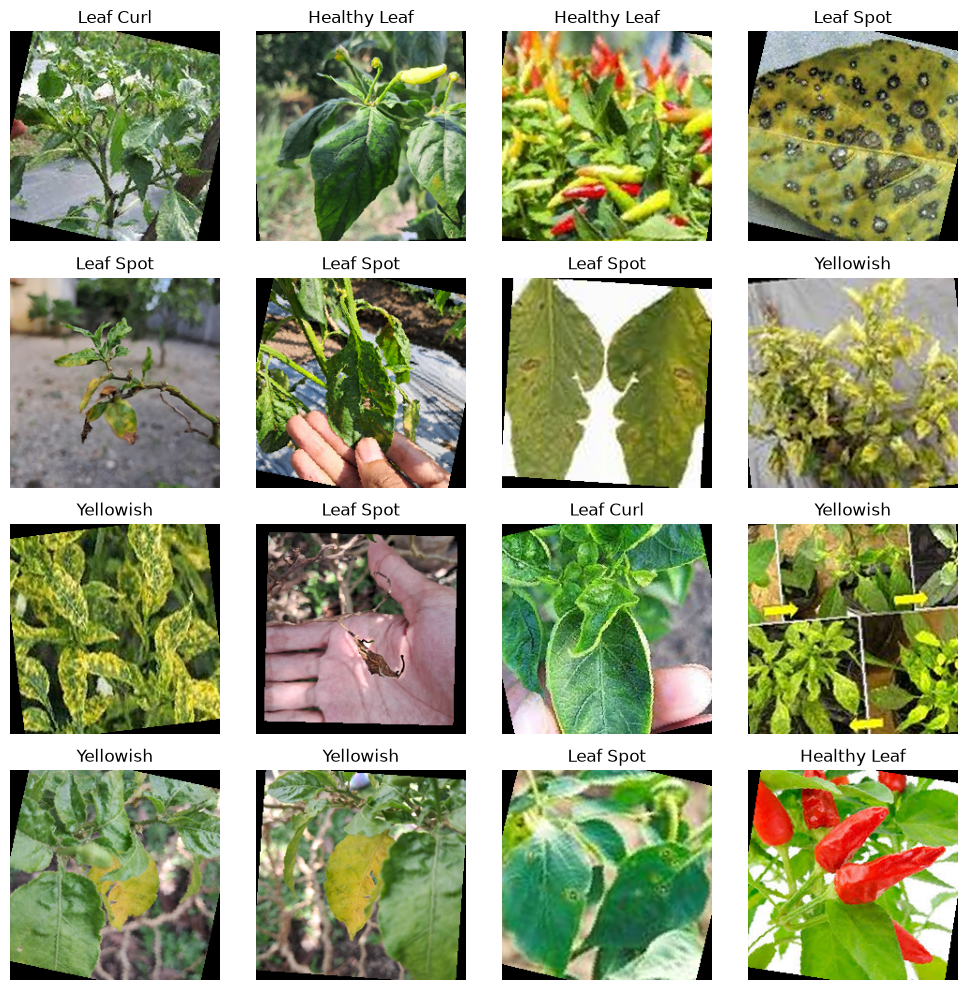

In [5]:
# Visualisasi 4x4 sampel train yang sudah diaugmentasi.
def denormalize(image_tensor) :
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (image_tensor.cpu() * std + mean).clamp(0, 1)

sample_indices = np.random.default_rng(seed).choice(len(train_dataset), size=min(16, len(train_dataset)), replace=False)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for axis, sample_index in zip(axes.flat, sample_indices) :
    image, target = train_dataset[sample_index]
    axis.imshow(denormalize(image).permute(1, 2, 0))
    axis.set_title(CLASS_DISPLAY_NAMES.get(class_names[target], class_names[target]))
    axis.axis("off")
for axis in axes.flat[len(sample_indices):] :
    axis.axis("off")
plt.tight_layout()
plt.show()

# 4. CALLBACK

In [6]:
class EarlyStopping :
    def __init__(self, patience=PATIENCE) :
        self.patience = patience
        self.best_loss = float("inf")
        self.best_state_dict = None
        self.wait = 0

    def __call__(self, val_loss, model) :
        if val_loss < self.best_loss :
            self.best_loss = val_loss
            self.best_state_dict = copy.deepcopy(model.state_dict())
            self.wait = 0
            return False
        self.wait += 1
        return self.wait >= self.patience

    def restore(self, model) :
        if self.best_state_dict is None :
            raise RuntimeError("Belum ada state terbaik untuk dipulihkan.")
        model.load_state_dict(self.best_state_dict)

def save_checkpoint(model, path, **metadata) :
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"model_state_dict": model.state_dict(), **metadata}, path)
    return path

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
print("AMP enabled :", scaler.is_enabled())

AMP enabled : True


# 5. FUNCTION EVALUASI

In [7]:
def evaluate_loss_accuracy(model, loader) :
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_items = 0
    with torch.no_grad() :
        for images, targets in loader :
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            total_loss += criterion(logits, targets).item() * targets.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_items += targets.size(0)
    if total_items == 0 :
        raise ValueError("Loader evaluasi kosong.")
    return total_loss / total_items, total_correct / total_items

def predict_all(model, loader) :
    model.eval()
    y_true, y_pred, probs = [], [], []
    with torch.no_grad() :
        for images, targets in loader :
            logits = model(images.to(device))
            batch_probs = torch.softmax(logits, dim=1)
            y_true.extend(targets.numpy().tolist())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())
            probs.append(batch_probs.cpu().numpy())
    return np.asarray(y_true), np.asarray(y_pred), np.concatenate(probs, axis=0) if probs else np.empty((0, NUM_CLASSES))

def compute_metrics(y_true, y_pred, probs, loss) :
    del probs
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "loss": float(loss),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "classification_report": classification_report(y_true, y_pred, output_dict=True, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES)),
    }

def count_parameters(model) :
    return sum(parameter.numel() for parameter in model.parameters())

def model_size_mb(model) :
    temporary_path = None
    try :
        with tempfile.NamedTemporaryFile(suffix=".pth", delete=False) as temporary_file :
            temporary_path = temporary_file.name
        torch.save(model.state_dict(), temporary_path)
        return Path(temporary_path).stat().st_size / (1024 ** 2)
    finally :
        if temporary_path and Path(temporary_path).exists() :
            Path(temporary_path).unlink()

def measure_latency(model, warmup=20, runs=100) :
    model.eval()
    sample = torch.zeros(1, 3, IMG_SIZE[0], IMG_SIZE[1], device=device)
    timings = []
    with torch.no_grad() :
        for _ in range(warmup) :
            model(sample)
        if device.type == "cuda" :
            torch.cuda.synchronize()
        for _ in range(runs) :
            start = time.perf_counter()
            model(sample)
            if device.type == "cuda" :
                torch.cuda.synchronize()
            timings.append((time.perf_counter() - start) * 1000)
    return float(np.mean(timings)), float(np.std(timings))

# 6. MODEL

## A. MobileNetV2

## B. EfficientNetB0

## C. Hybrid Fusion

In [8]:
from torchvision import models

In [9]:
def make_head(input_features, dropout) :
    return nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(input_features, HIDDEN_DIM),
        nn.ReLU(),
        nn.Dropout(p=dropout),
        nn.Linear(HIDDEN_DIM, NUM_CLASSES),
    )

class FeatureBackbone(nn.Module) :
    def __init__(self, features) :
        super().__init__()
        self.features = features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()

    def forward(self, images) :
        return self.flatten(self.pool(self.features(images)))

class SingleBackboneModel(nn.Module) :
    def __init__(self, features, backbone_name, dropout) :
        super().__init__()
        self.features = features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = make_head(1280, dropout)
        self.backbone_name = backbone_name

    def forward(self, images) :
        features = self.pool(self.features(images)).flatten(1)
        return self.head(features)

class FusionModel(nn.Module) :
    def __init__(self, mobilenet_features, efficientnet_features, dropout) :
        super().__init__()
        self.mobilenet = FeatureBackbone(mobilenet_features)
        self.efficientnet = FeatureBackbone(efficientnet_features)
        self.head = make_head(2560, dropout)

    def forward(self, images) :
        mobilenet_features = self.mobilenet(images)
        efficientnet_features = self.efficientnet(images)
        fused_features = torch.cat((mobilenet_features, efficientnet_features), dim=1)
        return self.head(fused_features)


def build_mobilenet(dropout) :
    backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    assert len(backbone.features) == 19
    return SingleBackboneModel(backbone.features, "mobilenet", dropout).to(device)


def build_efficientnet(dropout) :
    backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    assert len(backbone.features) == 9
    return SingleBackboneModel(backbone.features, "efficientnet", dropout).to(device)


def build_hybrid(dropout) :
    mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    assert len(mobilenet.features) == 19
    assert len(efficientnet.features) == 9
    return FusionModel(mobilenet.features, efficientnet.features, dropout).to(device)


def _backbone_parts(model) :
    if isinstance(model, FusionModel) :
        return [("MobileNetV2", model.mobilenet), ("EfficientNetB0", model.efficientnet)]
    return [(model.backbone_name, model)]


def _last_conv_channels(module) :
    channels = [layer.out_channels for layer in module.modules() if isinstance(layer, nn.Conv2d)]
    if not channels :
        raise RuntimeError("Tidak menemukan Conv2d pada stage backbone.")
    return channels[-1]


def print_unfrozen_stage_channels(model) :
    for backbone_name, backbone in _backbone_parts(model) :
        start_index = 14 if backbone_name == "mobilenet" else 6
        print(backbone_name, "features[" + str(start_index) + ":] channels :", {
            index: _last_conv_channels(backbone.features[index])
            for index in range(start_index, len(backbone.features))
        })


def freeze_backbone(model) :
    for parameter in model.parameters() :
        parameter.requires_grad = False
    for parameter in model.head.parameters() :
        parameter.requires_grad = True
    return model


def unfreeze_last_stages(model) :
    freeze_backbone(model)
    for backbone_name, backbone in _backbone_parts(model) :
        start_index = 14 if backbone_name == "mobilenet" else 6
        for module in backbone.features[start_index:] :
            for parameter in module.parameters() :
                parameter.requires_grad = True
    print_unfrozen_stage_channels(model)
    return model


def set_train_mode(model, stage) :
    if stage not in (1, 2) :
        raise ValueError("stage harus 1 atau 2.")
    model.train()
    for _, backbone in _backbone_parts(model) :
        if stage == 1 :
            backbone.eval()
        else :
            for module in backbone.modules() :
                if module is backbone :
                    continue
                if any(parameter.requires_grad for parameter in module.parameters(recurse=False)) :
                    module.train()
                else :
                    module.eval()
    for module in model.modules() :
        if isinstance(module, nn.modules.batchnorm._BatchNorm) :
            module.eval()
    return model

mobilenet_model = build_mobilenet(BASE_CONFIG["dropout"])
efficientnet_model = build_efficientnet(BASE_CONFIG["dropout"])
hybrid_model = build_hybrid(BASE_CONFIG["dropout"])
print_unfrozen_stage_channels(hybrid_model)

MobileNetV2 features[6:] channels : {6: 32, 7: 64, 8: 64, 9: 64, 10: 64, 11: 96, 12: 96, 13: 96, 14: 160, 15: 160, 16: 160, 17: 320, 18: 1280}
EfficientNetB0 features[6:] channels : {6: 192, 7: 320, 8: 1280}


In [10]:
def set_train_mode(model, stage) :
    if stage not in (1, 2) :
        raise ValueError("stage harus 1 atau 2.")
    model.train()
    for _, backbone in _backbone_parts(model) :
        if isinstance(model, FusionModel) :
            if stage == 1 :
                backbone.eval()
            else :
                backbone.train()
        elif stage == 1 :
            backbone.features.eval()
        else :
            backbone.features.train()
    for module in model.modules() :
        if isinstance(module, nn.modules.batchnorm._BatchNorm) :
            module.eval()
    return model

In [11]:
def _backbone_parts(model) :
    if isinstance(model, FusionModel) :
        return [("mobilenet", model.mobilenet), ("efficientnet", model.efficientnet)]
    return [(model.backbone_name, model)]


def _stage_start(backbone_name) :
    return 14 if backbone_name == "mobilenet" else 6


def print_unfrozen_stage_channels(model) :
    for backbone_name, backbone in _backbone_parts(model) :
        start_index = _stage_start(backbone_name)
        print(backbone_name, "features[" + str(start_index) + ":] channels :", {
            index: _last_conv_channels(backbone.features[index])
            for index in range(start_index, len(backbone.features))
        })


def unfreeze_last_stages(model) :
    freeze_backbone(model)
    for backbone_name, backbone in _backbone_parts(model) :
        start_index = _stage_start(backbone_name)
        for module in backbone.features[start_index:] :
            for parameter in module.parameters() :
                parameter.requires_grad = True
    print_unfrozen_stage_channels(model)
    return model

print_unfrozen_stage_channels(hybrid_model)

mobilenet features[14:] channels : {14: 160, 15: 160, 16: 160, 17: 320, 18: 1280}
efficientnet features[6:] channels : {6: 192, 7: 320, 8: 1280}


# 7. TRAINING FUNCTION (2 Tahap)

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, stage, max_batches=None) :
    set_train_mode(model, stage)
    epoch_start = time.perf_counter()
    running_loss = 0.0
    running_correct = 0
    total_items = 0
    for batch_index, (images, targets) in enumerate(loader) :
        if max_batches is not None and batch_index >= max_batches :
            break
        images, targets = images.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda") :
            logits = model(images)
            loss = criterion(logits, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * targets.size(0)
        running_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_items += targets.size(0)
    if total_items == 0 :
        raise ValueError("Loader training kosong atau max_batches terlalu kecil.")
    epoch_sec = time.perf_counter() - epoch_start
    return running_loss / total_items, running_correct / total_items, epoch_sec


def fit_stage(model, train_loader, val_loader, optimizer, max_epochs=STAGE_MAX_EPOCHS, patience=PATIENCE, stage=1) :
    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=patience)
    history = []
    best_epoch = 0
    for epoch in range(1, max_epochs + 1) :
        train_loss, train_acc, epoch_sec = train_one_epoch(model, train_loader, criterion, optimizer, scaler, stage)
        val_loss, val_acc = evaluate_loss_accuracy(model, val_loader)
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "epoch_sec": epoch_sec,
        }
        history.append(row)
        print(
            f"stage={stage} epoch={epoch}/{max_epochs} "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
            f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} sec={epoch_sec:.2f}"
        )
        if val_loss < early_stopping.best_loss :
            best_epoch = epoch
        if early_stopping(val_loss, model) :
            break
    early_stopping.restore(model)
    return history, best_epoch, len(history)


def build_optimizer(model, cfg, lr) :
    parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
    if not parameters :
        raise ValueError("Tidak ada parameter trainable untuk optimizer.")
    if cfg["optimizer"] == "Adam" :
        return torch.optim.Adam(parameters, lr=lr, weight_decay=0.0)
    if cfg["optimizer"] == "AdamW" :
        return torch.optim.AdamW(parameters, lr=lr, weight_decay=0.01)
    raise ValueError(f"Optimizer tidak didukung: {cfg['optimizer']}")


def train_model(model, cfg, seed, name, max_epochs=None, stage1_max_epochs=None, stage2_max_epochs=None) :
    seed_everything(seed)
    stage1_epochs = stage1_max_epochs if stage1_max_epochs is not None else (max_epochs or STAGE_MAX_EPOCHS)
    stage2_epochs = stage2_max_epochs if stage2_max_epochs is not None else (max_epochs or STAGE_MAX_EPOCHS)
    train_loader, validation_loader = make_loaders(cfg["batch_size"], seed)
    criterion = nn.CrossEntropyLoss()
    total_start = time.perf_counter()

    freeze_backbone(model)
    stage1_optimizer = build_optimizer(model, cfg, cfg["lr"])
    stage1_start = time.perf_counter()
    history_stage1, best_epoch_stage1, epochs_stage1 = fit_stage(
        model, train_loader, validation_loader, stage1_optimizer,
        max_epochs=stage1_epochs, patience=PATIENCE, stage=1,
    )
    stage1_sec = time.perf_counter() - stage1_start

    unfreeze_last_stages(model)
    stage2_optimizer = build_optimizer(model, cfg, cfg["lr"] / FINE_TUNE_LR_DIV)
    stage2_start = time.perf_counter()
    history_stage2, best_epoch_stage2, epochs_stage2 = fit_stage(
        model, train_loader, validation_loader, stage2_optimizer,
        max_epochs=stage2_epochs, patience=PATIENCE, stage=2,
    )
    stage2_sec = time.perf_counter() - stage2_start

    checkpoint_path = CHECKPOINT_DIR / f"{name}_seed{seed}.pth"
    save_checkpoint(
        model,
        checkpoint_path,
        name=name,
        seed=seed,
        config=cfg,
        best_epoch_stage1=best_epoch_stage1,
        best_epoch_stage2=best_epoch_stage2,
        history={"stage1": history_stage1, "stage2": history_stage2},
    )
    all_epoch_seconds = [row["epoch_sec"] for row in history_stage1 + history_stage2]
    timing = {
        "total_sec": time.perf_counter() - total_start,
        "stage1_sec": stage1_sec,
        "stage2_sec": stage2_sec,
        "epoch_sec_mean": float(np.mean(all_epoch_seconds)),
        "epochs_run": epochs_stage1 + epochs_stage2,
    }
    return model, {"stage1": history_stage1, "stage2": history_stage2}, timing

In [15]:
# Smoke test model dan training sesuai konfigurasi pilot.
seed_everything(seed)
probe = torch.randn(2, 3, IMG_SIZE[0], IMG_SIZE[1], device=device)
with torch.no_grad() :
    mobilenet_logits = mobilenet_model(probe)
    efficientnet_logits = efficientnet_model(probe)
    hybrid_logits = hybrid_model(probe)
    mobilenet_vector = hybrid_model.mobilenet(probe)
    efficientnet_vector = hybrid_model.efficientnet(probe)
    fused_vector = torch.cat((mobilenet_vector, efficientnet_vector), dim=1)
assert mobilenet_logits.shape == (2, NUM_CLASSES)
assert efficientnet_logits.shape == (2, NUM_CLASSES)
assert hybrid_logits.shape == (2, NUM_CLASSES)
assert mobilenet_vector.shape[1] == 1280
assert efficientnet_vector.shape[1] == 1280
assert fused_vector.shape == (2, 2560)
print("Forward shapes :", mobilenet_logits.shape, efficientnet_logits.shape, hybrid_logits.shape)
print("Hybrid concat shape :", fused_vector.shape)

for model_name, model in (("MobileNetV2", mobilenet_model), ("EfficientNetB0", efficientnet_model), ("Hybrid", hybrid_model)) :
    freeze_backbone(model)
    frozen_backbone = [parameter for name, parameter in model.named_parameters() if "head" not in name]
    assert frozen_backbone and all(not parameter.requires_grad for parameter in frozen_backbone)
    print(model_name, "stage 1 total/trainable :", count_parameters(model), sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad))
    unfreeze_last_stages(model)
    print(model_name, "stage 2 total/trainable :", count_parameters(model), sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad))

smoke_model = build_mobilenet(BASE_CONFIG["dropout"])
smoke_model, smoke_history, smoke_timing = train_model(
    smoke_model,
    BASE_CONFIG,
    seed=SEEDS[0],
    name="MobileNetV2_smoke",
    max_epochs=2,
)
print("MobileNetV2 smoke timing :", smoke_timing)
print("MobileNetV2 stage 1 losses :", [round(row["train_loss"], 4) for row in smoke_history["stage1"]])
print("MobileNetV2 stage 2 losses :", [round(row["train_loss"], 4) for row in smoke_history["stage2"]])

hybrid_smoke = build_hybrid(BASE_CONFIG["dropout"])
hybrid_cfg = {**BASE_CONFIG, "batch_size": 32}
try :
    seed_everything(seed)
    unfreeze_last_stages(hybrid_smoke)
    hybrid_optimizer = build_optimizer(hybrid_smoke, hybrid_cfg, hybrid_cfg["lr"] / FINE_TUNE_LR_DIV)
    hybrid_train_loader, _ = make_loaders(hybrid_cfg["batch_size"], seed)
    torch.cuda.reset_peak_memory_stats() if torch.cuda.is_available() else None
    hybrid_loss, hybrid_acc, hybrid_sec = train_one_epoch(
        hybrid_smoke,
        hybrid_train_loader,
        nn.CrossEntropyLoss(),
        hybrid_optimizer,
        scaler,
        stage=2,
        max_batches=3,
    )
    peak_vram_gb = torch.cuda.max_memory_allocated() / (1024 ** 3) if torch.cuda.is_available() else 0.0
    print(f"Hybrid batch 32, 3 batches: loss={hybrid_loss:.4f}, acc={hybrid_acc:.4f}, sec={hybrid_sec:.2f}")
    print(f"Hybrid peak VRAM (GB) : {peak_vram_gb:.4f}")
except torch.cuda.OutOfMemoryError as error :
    print("Hybrid batch 32 OOM :", error)
    if torch.cuda.is_available() :
        torch.cuda.empty_cache()
finally :
    del probe, smoke_model, hybrid_smoke
    gc.collect()
    if torch.cuda.is_available() :
        torch.cuda.empty_cache()

Forward shapes : torch.Size([2, 4]) torch.Size([2, 4]) torch.Size([2, 4])
Hybrid concat shape : torch.Size([2, 2560])
MobileNetV2 stage 1 total/trainable : 2881796 657924
mobilenet features[14:] channels : {14: 160, 15: 160, 16: 160, 17: 320, 18: 1280}
MobileNetV2 stage 2 total/trainable : 2881796 2339268
EfficientNetB0 stage 1 total/trainable : 4665472 657924
efficientnet features[6:] channels : {6: 192, 7: 320, 8: 1280}
EfficientNetB0 stage 2 total/trainable : 4665472 3813664
Hybrid stage 1 total/trainable : 7544704 1313284
mobilenet features[14:] channels : {14: 160, 15: 160, 16: 160, 17: 320, 18: 1280}
efficientnet features[6:] channels : {6: 192, 7: 320, 8: 1280}
Hybrid stage 2 total/trainable : 7544704 6150368
stage=1 epoch=1/2 train_loss=1.3735 val_loss=1.3584 train_acc=0.2857 val_acc=0.3333 sec=9.48
stage=1 epoch=2/2 train_loss=1.3095 val_loss=1.3415 train_acc=0.5929 val_acc=0.4667 sec=0.63
mobilenet features[14:] channels : {14: 160, 15: 160, 16: 160, 17: 320, 18: 1280}
stage=

# 8. TRAIN & EVALUASI MODEL

In [13]:
import json
import re
import seaborn as sns

EVAL_REPORT_DIR = Path("reports")
EVAL_FIG_DIR = EVAL_REPORT_DIR / "figures"
EVAL_METRICS_DIR = EVAL_REPORT_DIR / "metrics"
EVAL_FIG_DIR.mkdir(parents=True, exist_ok=True)
EVAL_METRICS_DIR.mkdir(parents=True, exist_ok=True)
TEST_MANIFEST_PATH = Path("data/splits") / RUN_TAG / "test.csv"


def _json_safe(value) :
    if isinstance(value, np.ndarray) :
        return value.tolist()
    if isinstance(value, (np.integer, np.floating)) :
        return value.item()
    if isinstance(value, dict) :
        return {str(key): _json_safe(item) for key, item in value.items()}
    if isinstance(value, list) :
        return [_json_safe(item) for item in value]
    return value


def _safe_name(value) :
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", value).strip("_")


def _source_metrics(y_true, y_pred, source_names) :
    result = {}
    for source in ("primer", "sekunder") :
        mask = np.asarray(source_names) == source
        if not np.any(mask) :
            result[source] = {"n": 0, "accuracy": None, "f1": None}
            continue
        result[source] = {
            "n": int(mask.sum()),
            "accuracy": float(accuracy_score(y_true[mask], y_pred[mask])),
            "f1": float(f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0)),
        }
    return result


def run_experiment(variant_name, builder, cfg, seed) :
    model = builder(cfg["dropout"])
    model, history, timing = train_model(model, cfg, seed, variant_name)
    # Test loader hanya boleh dipanggil di evaluasi final.
    test_loader = make_test_loader(cfg["batch_size"])
    test_loss, _ = evaluate_loss_accuracy(model, test_loader)
    y_true, y_pred, probs = predict_all(model, test_loader)
    test_metrics = compute_metrics(y_true, y_pred, probs, test_loss)
    params_total = count_parameters(model)
    size_mb = model_size_mb(model)
    latency_mean, latency_std = measure_latency(model)

    test_manifest = pd.read_csv(TEST_MANIFEST_PATH)
    image_ids = [Path(path).stem for path, _ in test_dataset.samples]
    source_lookup = test_manifest.set_index("image_id")["source"].to_dict()
    source_names = np.asarray([source_lookup[image_id] for image_id in image_ids])
    source_metrics = _source_metrics(y_true, y_pred, source_names)
    best_epoch_stage1 = min(history["stage1"], key=lambda row: row["val_loss"])["epoch"]
    best_epoch_stage2 = min(history["stage2"], key=lambda row: row["val_loss"])["epoch"]
    run_row = {
        "variant": variant_name,
        "seed": seed,
        "optimizer": cfg["optimizer"],
        "lr": cfg["lr"],
        "dropout": cfg["dropout"],
        "batch_size": cfg["batch_size"],
        "best_epoch_stage1": best_epoch_stage1,
        "best_epoch_stage2": best_epoch_stage2,
        "epochs_run": timing["epochs_run"],
        "train_time_sec": timing["total_sec"],
        "test_acc": test_metrics["accuracy"],
        "test_loss": test_metrics["loss"],
        "macro_precision": test_metrics["precision"],
        "macro_recall": test_metrics["recall"],
        "macro_f1": test_metrics["f1"],
        "params_total": params_total,
        "size_mb": size_mb,
        "latency_ms_mean": latency_mean,
        "latency_ms_std": latency_std,
        "n_primer": source_metrics["primer"]["n"],
        "n_sekunder": source_metrics["sekunder"]["n"],
        "acc_primer": source_metrics["primer"]["accuracy"],
        "acc_sekunder": source_metrics["sekunder"]["accuracy"],
        "f1_primer": source_metrics["primer"]["f1"],
        "f1_sekunder": source_metrics["sekunder"]["f1"],
    }
    runs_path = EVAL_METRICS_DIR / "runs.csv"
    runs_frame = pd.DataFrame([run_row])
    if runs_path.exists() :
        existing_runs = pd.read_csv(runs_path)
        existing_runs = existing_runs[~((existing_runs["variant"] == variant_name) & (existing_runs["seed"] == seed))]
        runs_frame = pd.concat([existing_runs, runs_frame], ignore_index=True)
    runs_frame.to_csv(runs_path, index=False)

    result_payload = {
        "variant": variant_name,
        "seed": seed,
        "metrics": test_metrics,
        "source_metrics": source_metrics,
        "history": history,
        "timing": timing,
        "params_total": params_total,
        "size_mb": size_mb,
        "latency_ms_mean": latency_mean,
        "latency_ms_std": latency_std,
    }
    result_path = EVAL_METRICS_DIR / f"results_{_safe_name(variant_name)}_seed{seed}.json"
    result_path.write_text(json.dumps(_json_safe(result_payload), indent=2), encoding="utf-8")
    del model, test_loader
    gc.collect()
    if torch.cuda.is_available() :
        torch.cuda.empty_cache()
    return run_row, result_payload

## A. MobileNetV2

In [17]:
mobilenet_runs = []
for run_seed in SEEDS :
    run_row, run_payload = run_experiment("MobileNetV2", build_mobilenet, BASE_CONFIG, run_seed)
    mobilenet_runs.append(run_row)
print(pd.DataFrame(mobilenet_runs))

stage=1 epoch=1/50 train_loss=1.3753 val_loss=1.3648 train_acc=0.2857 val_acc=0.3333 sec=0.92
stage=1 epoch=2/50 train_loss=1.3146 val_loss=1.3519 train_acc=0.5786 val_acc=0.3667 sec=0.54
stage=1 epoch=3/50 train_loss=1.2583 val_loss=1.3372 train_acc=0.7000 val_acc=0.4667 sec=0.56
stage=1 epoch=4/50 train_loss=1.2146 val_loss=1.3185 train_acc=0.6929 val_acc=0.5000 sec=0.60
stage=1 epoch=5/50 train_loss=1.1585 val_loss=1.3031 train_acc=0.7286 val_acc=0.5333 sec=0.61
stage=1 epoch=6/50 train_loss=1.1212 val_loss=1.2829 train_acc=0.7571 val_acc=0.5333 sec=0.63
stage=1 epoch=7/50 train_loss=1.0614 val_loss=1.2668 train_acc=0.7571 val_acc=0.5333 sec=0.66
stage=1 epoch=8/50 train_loss=1.0113 val_loss=1.2444 train_acc=0.7929 val_acc=0.5667 sec=0.68
stage=1 epoch=9/50 train_loss=0.9756 val_loss=1.2247 train_acc=0.8000 val_acc=0.5667 sec=0.65
stage=1 epoch=10/50 train_loss=0.9272 val_loss=1.2080 train_acc=0.7786 val_acc=0.5667 sec=0.65
stage=1 epoch=11/50 train_loss=0.8747 val_loss=1.1914 train

## B. EfficientNetB0

In [18]:
efficientnet_runs = []
for run_seed in SEEDS :
    run_row, run_payload = run_experiment("EfficientNetB0", build_efficientnet, BASE_CONFIG, run_seed)
    efficientnet_runs.append(run_row)
print(pd.DataFrame(efficientnet_runs))

stage=1 epoch=1/50 train_loss=1.3725 val_loss=1.3369 train_acc=0.3214 val_acc=0.3667 sec=7.88
stage=1 epoch=2/50 train_loss=1.2584 val_loss=1.2995 train_acc=0.7143 val_acc=0.5333 sec=0.63
stage=1 epoch=3/50 train_loss=1.1614 val_loss=1.2550 train_acc=0.7286 val_acc=0.6000 sec=0.58
stage=1 epoch=4/50 train_loss=1.0863 val_loss=1.2104 train_acc=0.7500 val_acc=0.6333 sec=0.59
stage=1 epoch=5/50 train_loss=1.0143 val_loss=1.1668 train_acc=0.7500 val_acc=0.6333 sec=0.61
stage=1 epoch=6/50 train_loss=0.9516 val_loss=1.1212 train_acc=0.7643 val_acc=0.6667 sec=0.65
stage=1 epoch=7/50 train_loss=0.8746 val_loss=1.0855 train_acc=0.8071 val_acc=0.6667 sec=0.63
stage=1 epoch=8/50 train_loss=0.8116 val_loss=1.0516 train_acc=0.8214 val_acc=0.6667 sec=0.63
stage=1 epoch=9/50 train_loss=0.7318 val_loss=1.0128 train_acc=0.8571 val_acc=0.6333 sec=0.66
stage=1 epoch=10/50 train_loss=0.6973 val_loss=0.9772 train_acc=0.8143 val_acc=0.7000 sec=0.66
stage=1 epoch=11/50 train_loss=0.6427 val_loss=0.9515 train

## C. Hybrid (base config)

In [19]:
hybrid_runs = []
for run_seed in SEEDS :
    run_row, run_payload = run_experiment("Hybrid (base config)", build_hybrid, BASE_CONFIG, run_seed)
    hybrid_runs.append(run_row)
print(pd.DataFrame(hybrid_runs))

stage=1 epoch=1/50 train_loss=1.3865 val_loss=1.3593 train_acc=0.2786 val_acc=0.3000 sec=0.91
stage=1 epoch=2/50 train_loss=1.3227 val_loss=1.3367 train_acc=0.4000 val_acc=0.3333 sec=0.69
stage=1 epoch=3/50 train_loss=1.2639 val_loss=1.3096 train_acc=0.5429 val_acc=0.5667 sec=0.71
stage=1 epoch=4/50 train_loss=1.1842 val_loss=1.2812 train_acc=0.6357 val_acc=0.5667 sec=0.67
stage=1 epoch=5/50 train_loss=1.1392 val_loss=1.2551 train_acc=0.6714 val_acc=0.5667 sec=0.69
stage=1 epoch=6/50 train_loss=1.0904 val_loss=1.2240 train_acc=0.6214 val_acc=0.6333 sec=0.69
stage=1 epoch=7/50 train_loss=1.0314 val_loss=1.1978 train_acc=0.7143 val_acc=0.6333 sec=0.69
stage=1 epoch=8/50 train_loss=0.9934 val_loss=1.1701 train_acc=0.7643 val_acc=0.6667 sec=0.68
stage=1 epoch=9/50 train_loss=0.8964 val_loss=1.1400 train_acc=0.8071 val_acc=0.6333 sec=0.70
stage=1 epoch=10/50 train_loss=0.8735 val_loss=1.1103 train_acc=0.7643 val_acc=0.6333 sec=0.67
stage=1 epoch=11/50 train_loss=0.8261 val_loss=1.0852 train

# 9. PERBANDINGAN HASIL

In [14]:
def _format_mean_std(series) :
    values = pd.to_numeric(series, errors="coerce").dropna()
    if len(values) == 0 :
        return ""
    if len(values) == 1 :
        return f"{values.iloc[0]:.4f}"
    return f"{values.mean():.4f} +/- {values.std(ddof=1):.4f}"


def load_result_payloads(runs_frame) :
    payloads = []
    for _, run in runs_frame.sort_values(["variant", "seed"]).iterrows() :
        result_path = EVAL_METRICS_DIR / f"results_{_safe_name(run['variant'])}_seed{int(run['seed'])}.json"
        if result_path.exists() :
            payloads.append(json.loads(result_path.read_text(encoding="utf-8")))
    return payloads


def build_comparison_tables() :
    runs_frame = pd.read_csv(EVAL_METRICS_DIR / "runs.csv")
    main_rows = []
    for variant, group in runs_frame.groupby("variant", sort=True) :
        main_rows.append({
            "Model": variant,
            "Accuracy": _format_mean_std(group["test_acc"]),
            "Precision macro": _format_mean_std(group["macro_precision"]),
            "Recall macro": _format_mean_std(group["macro_recall"]),
            "F1 macro": _format_mean_std(group["macro_f1"]),
            "Params": int(group["params_total"].iloc[0]),
            "Ukuran MB": _format_mean_std(group["size_mb"]),
            "Inferensi ms/citra": _format_mean_std(group["latency_ms_mean"]),
        })
    comparison_main = pd.DataFrame(main_rows)

    per_class_rows = []
    for payload in load_result_payloads(runs_frame) :
        if any(row["Model"] == payload["variant"] for row in per_class_rows) :
            continue
        report = payload["metrics"]["classification_report"]
        for class_index, class_name in enumerate(class_names) :
            class_report = report.get(str(class_index), {})
            per_class_rows.append({
                "Model": payload["variant"],
                "Kelas": CLASS_DISPLAY_NAMES.get(class_name, class_name),
                "Precision": class_report.get("precision", 0.0),
                "Recall": class_report.get("recall", 0.0),
                "F1": class_report.get("f1-score", 0.0),
            })
    per_class = pd.DataFrame(per_class_rows)
    source_rows = []
    for variant, group in runs_frame.groupby("variant", sort=True) :
        source_rows.append({
            "Model": variant,
            "n primer": int(round(group["n_primer"].mean())),
            "Acc primer": _format_mean_std(group["acc_primer"]),
            "F1 primer": _format_mean_std(group["f1_primer"]),
            "n sekunder": int(round(group["n_sekunder"].mean())),
            "Acc sekunder": _format_mean_std(group["acc_sekunder"]),
            "F1 sekunder": _format_mean_std(group["f1_sekunder"]),
        })
    per_source = pd.DataFrame(source_rows)
    return runs_frame, comparison_main, per_class, per_source


runs_frame, comparison_main, per_class, per_source = build_comparison_tables()
print(f"Test set : {len(test_dataset)} citra; 1 citra salah = {100 / len(test_dataset):.2f}% akurasi")
if RUN_TAG == "pilot" :
    print("Hasil pilot hanya digunakan untuk menguji pipeline, bukan untuk kesimpulan performa final.")
print("\nTabel utama")
display(comparison_main)
print("\nTabel per kelas")
display(per_class)
print("\nTabel per source")
display(per_source)

Test set : 30 citra; 1 citra salah = 3.33% akurasi
Hasil pilot hanya digunakan untuk menguji pipeline, bukan untuk kesimpulan performa final.

Tabel utama


,Model,Accuracy,Precision macro,Recall macro,F1 macro,Params,Ukuran MB,Inferensi ms/citra
0,EfficientNetB0,0.8333,0.8299,0.8304,0.8247,4665472,18.0840,9.9868
1,Hybrid (base config),0.7667,0.7604,0.7634,0.7601,7544704,29.3145,16.5416
2,MobileNetV2,0.7000,0.6994,0.7009,0.6955,2881796,11.2284,6.2062



Tabel per kelas


,Model,Kelas,Precision,Recall,F1
0,EfficientNetB0,Healthy Leaf,0.875000,0.875000,0.875000
1,EfficientNetB0,Leaf Curl,0.666667,0.571429,0.615385
2,EfficientNetB0,Leaf Spot,1.000000,0.875000,0.933333
3,EfficientNetB0,Yellowish,0.777778,1.000000,0.875000
4,Hybrid (base config),Healthy Leaf,0.750000,0.750000,0.750000
5,Hybrid (base config),Leaf Curl,0.666667,0.571429,0.615385
6,Hybrid (base config),Leaf Spot,0.875000,0.875000,0.875000
7,Hybrid (base config),Yellowish,0.750000,0.857143,0.800000
8,MobileNetV2,Healthy Leaf,0.714286,0.625000,0.666667
9,MobileNetV2,Leaf Curl,0.666667,0.571429,0.615385



Tabel per source


,Model,n primer,Acc primer,F1 primer,n sekunder,Acc sekunder,F1 sekunder
0,EfficientNetB0,13,0.8462,0.8389,17,0.8235,0.8201
1,Hybrid (base config),13,0.8462,0.8667,17,0.7059,0.7278
2,MobileNetV2,13,0.6923,0.7143,17,0.7059,0.7278


# 10. VISUALISASI HASIL DAN PERFORMA

In [15]:
def _save_show_figure(figure, filename) :
    figure.savefig(EVAL_FIG_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()


def plot_training_curves() :
    payloads = load_result_payloads(runs_frame)
    figure, axes = plt.subplots(1, 2, figsize=(14, 5))
    for payload in payloads :
        rows = payload["history"]["stage1"] + payload["history"]["stage2"]
        epochs = np.arange(1, len(rows) + 1)
        label = f"{payload['variant']} seed {payload['seed']}"
        axes[0].plot(epochs, [row["train_loss"] for row in rows], label=f"train {label}", alpha=0.75)
        axes[0].plot(epochs, [row["val_loss"] for row in rows], linestyle="--", label=f"val {label}", alpha=0.75)
        axes[1].plot(epochs, [row["train_acc"] for row in rows], label=f"train {label}", alpha=0.75)
        axes[1].plot(epochs, [row["val_acc"] for row in rows], linestyle="--", label=f"val {label}", alpha=0.75)
        boundary = len(payload["history"]["stage1"]) + 0.5
        axes[0].axvline(boundary, color="black", alpha=0.15)
        axes[1].axvline(boundary, color="black", alpha=0.15)
    axes[0].set(title="Loss", xlabel="Epoch", ylabel="Loss")
    axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[0].legend(fontsize=7)
    axes[1].legend(fontsize=7)
    figure.tight_layout()
    _save_show_figure(figure, "training_curves.png")


def plot_confusion_matrices() :
    payloads = load_result_payloads(runs_frame)
    for payload in payloads :
        if any(previous["variant"] == payload["variant"] for previous in payloads if previous is not payload) :
            continue
        matrix = np.asarray(payload["metrics"]["confusion_matrix"])
        figure, axis = plt.subplots(figsize=(6, 5))
        sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis,
                    xticklabels=[CLASS_DISPLAY_NAMES.get(name, name) for name in class_names],
                    yticklabels=[CLASS_DISPLAY_NAMES.get(name, name) for name in class_names])
        axis.set(title=f"Confusion Matrix - {payload['variant']}", xlabel="Predicted", ylabel="True")
        figure.tight_layout()
        _save_show_figure(figure, f"confusion_matrix_{_safe_name(payload['variant'])}.png")


def plot_f1_per_class() :
    figure, axis = plt.subplots(figsize=(10, 5))
    sns.barplot(data=per_class, x="Kelas", y="F1", hue="Model", ax=axis)
    axis.set(title="F1-score per kelas", ylim=(0, 1))
    axis.tick_params(axis="x", rotation=20)
    figure.tight_layout()
    _save_show_figure(figure, "f1_per_class.png")


def plot_efficiency() :
    efficiency = runs_frame.groupby("variant", as_index=False)[["params_total", "size_mb", "latency_ms_mean"]].mean()
    figure, axes = plt.subplots(1, 3, figsize=(15, 5))
    for axis, column, title in zip(axes, ["params_total", "size_mb", "latency_ms_mean"], ["Parameter", "Ukuran model (MB)", "Latensi (ms)"]) :
        sns.barplot(data=efficiency, x="variant", y=column, ax=axis)
        axis.set(title=title, xlabel="", ylabel=column)
        axis.tick_params(axis="x", rotation=25)
    figure.tight_layout()
    _save_show_figure(figure, "efficiency.png")


def plot_tradeoff() :
    efficiency = runs_frame.groupby("variant", as_index=False)[["latency_ms_mean", "macro_f1"]].mean()
    figure, axis = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=efficiency, x="latency_ms_mean", y="macro_f1", hue="variant", s=140, ax=axis)
    axis.set(title="Trade-off macro F1 vs latensi", xlabel="Latensi (ms/citra)", ylabel="Macro F1")
    figure.tight_layout()
    _save_show_figure(figure, "tradeoff_f1_latency.png")

In [16]:
def plot_confusion_matrices() :
    payloads = load_result_payloads(runs_frame)
    seen_variants = set()
    for payload in payloads :
        if payload["variant"] in seen_variants :
            continue
        seen_variants.add(payload["variant"])
        matrix = np.asarray(payload["metrics"]["confusion_matrix"])
        figure, axis = plt.subplots(figsize=(6, 5))
        sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis,
                    xticklabels=[CLASS_DISPLAY_NAMES.get(name, name) for name in class_names],
                    yticklabels=[CLASS_DISPLAY_NAMES.get(name, name) for name in class_names])
        axis.set(title=f"Confusion Matrix - {payload['variant']}", xlabel="Predicted", ylabel="True")
        figure.tight_layout()
        _save_show_figure(figure, f"confusion_matrix_{_safe_name(payload['variant'])}.png")

# 11. EXPORT GRAFIK DAN TABEL KE FOLDER REPORTS

# 12. GRID SEARCH HYBRID

Grid total=48, selesai=2, dijalankan=2
stage=1 epoch=1/50 train_loss=1.2775 val_loss=1.2177 train_acc=0.4357 val_acc=0.5333 sec=16.91
stage=1 epoch=2/50 train_loss=0.7729 val_loss=0.9635 train_acc=0.7500 val_acc=0.6667 sec=0.70
stage=1 epoch=3/50 train_loss=0.5438 val_loss=0.8998 train_acc=0.8143 val_acc=0.5667 sec=0.68
stage=1 epoch=4/50 train_loss=0.3749 val_loss=0.8167 train_acc=0.8643 val_acc=0.6000 sec=0.68
stage=1 epoch=5/50 train_loss=0.2915 val_loss=0.7910 train_acc=0.9071 val_acc=0.6667 sec=0.68
stage=1 epoch=6/50 train_loss=0.2633 val_loss=0.7432 train_acc=0.9143 val_acc=0.7000 sec=0.68
stage=1 epoch=7/50 train_loss=0.1571 val_loss=0.7787 train_acc=0.9643 val_acc=0.7000 sec=0.68
stage=1 epoch=8/50 train_loss=0.1452 val_loss=0.7448 train_acc=0.9571 val_acc=0.7667 sec=0.67
stage=1 epoch=9/50 train_loss=0.1326 val_loss=0.7780 train_acc=0.9500 val_acc=0.7333 sec=0.65
stage=1 epoch=10/50 train_loss=0.0954 val_loss=0.6732 train_acc=0.9714 val_acc=0.8000 sec=0.65
stage=1 epoch=11/50

,optimizer,lr,dropout,batch_size,status,val_loss,val_acc,val_macro_f1,epochs_run,time_sec
0,Adam,0.001,0.2,32,ok,0.441226,0.866667,0.870833,23,60.791792
1,Adam,0.001,0.3,16,ok,0.470130,0.866667,0.870536,36,56.716928
2,Adam,0.001,0.2,16,ok,0.465311,0.866667,0.866071,29,132.227794
3,Adam,0.001,0.3,32,ok,0.494255,0.800000,0.805952,25,34.066251


BEST_HYBRID_CFG : {'optimizer': 'Adam', 'lr': 0.001, 'dropout': 0.2, 'batch_size': 32}


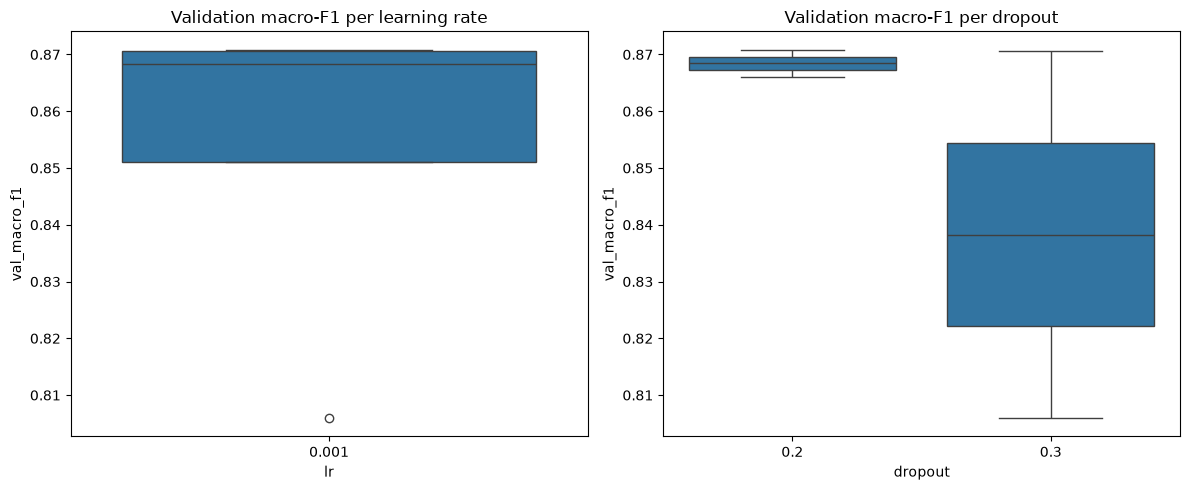

In [17]:
import itertools

GRID_LIMIT = 2
GRID_RESULTS_PATH = EVAL_METRICS_DIR / "grid_results.csv"
GRID_KEYS = ("optimizer", "lr", "dropout", "batch_size")


def _grid_key(config) :
    return tuple(str(config[key]) for key in GRID_KEYS)


def _read_completed_grid_keys() :
    if not GRID_RESULTS_PATH.exists() :
        return set()
    completed = pd.read_csv(GRID_RESULTS_PATH)
    return {
        _grid_key({key: row[key] for key in GRID_KEYS})
        for _, row in completed.iterrows()
    }


def _append_grid_result(row) :
    pd.DataFrame([row]).to_csv(
        GRID_RESULTS_PATH,
        mode="a",
        header=not GRID_RESULTS_PATH.exists(),
        index=False,
    )


def _grid_val_summary(history) :
    rows = history["stage1"] + history["stage2"]
    best_row = min(rows, key=lambda row: row["val_loss"])
    return best_row["val_loss"], best_row["val_acc"]


def run_hybrid_grid() :
    configurations = [
        dict(zip(GRID_KEYS, values))
        for values in itertools.product(*(GRID[key] for key in GRID_KEYS))
    ]
    completed_keys = _read_completed_grid_keys()
    pending = [config for config in configurations if _grid_key(config) not in completed_keys]
    if GRID_LIMIT is not None :
        pending = pending[:GRID_LIMIT]
    completed_times = []
    print(f"Grid total={len(configurations)}, selesai={len(completed_keys)}, dijalankan={len(pending)}")

    for index, config in enumerate(pending, start=1) :
        config_start = time.perf_counter()
        status = "ok"
        val_loss = None
        val_acc = None
        val_macro_f1 = None
        epochs_run = 0
        model = None
        try :
            model = build_hybrid(config["dropout"])
            model, history, timing = train_model(
                model,
                config,
                seed=42,
                name=f"Hybrid_grid_{config['optimizer']}_{config['lr']}_{config['dropout']}_{config['batch_size']}",
            )
            val_loss, val_acc = _grid_val_summary(history)
            _, validation_loader = make_loaders(config["batch_size"], 42)
            y_true, y_pred, probs = predict_all(model, validation_loader)
            val_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
            epochs_run = timing["epochs_run"]
        except torch.cuda.OutOfMemoryError as error :
            status = "oom"
            print("OOM:", error)
            if torch.cuda.is_available() :
                torch.cuda.empty_cache()
        finally :
            elapsed = time.perf_counter() - config_start
            completed_times.append(elapsed)
            _append_grid_result({
                "optimizer": config["optimizer"],
                "lr": config["lr"],
                "dropout": config["dropout"],
                "batch_size": config["batch_size"],
                "status": status,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "val_macro_f1": val_macro_f1,
                "epochs_run": epochs_run,
                "time_sec": elapsed,
            })
            del model
            gc.collect()
            if torch.cuda.is_available() :
                torch.cuda.empty_cache()
        finished = len(completed_times)
        eta = (sum(completed_times) / finished) * (len(pending) - finished)
        print(f"[{finished}/{len(pending)}] {config} status={status} time={elapsed:.1f}s ETA={eta:.1f}s")

    grid_results = pd.read_csv(GRID_RESULTS_PATH)
    grid_results = grid_results.sort_values(
        ["val_macro_f1", "val_loss"], ascending=[False, True], na_position="last",
    ).reset_index(drop=True)
    display(grid_results.head(10))
    valid_results = grid_results[grid_results["status"] == "ok"].dropna(subset=["val_macro_f1"])
    if valid_results.empty :
        raise RuntimeError("Tidak ada konfigurasi hybrid yang berhasil.")
    best_row = valid_results.iloc[0]
    global BEST_HYBRID_CFG
    BEST_HYBRID_CFG = {
        "optimizer": best_row["optimizer"],
        "lr": float(best_row["lr"]),
        "dropout": float(best_row["dropout"]),
        "batch_size": int(best_row["batch_size"]),
    }
    (EVAL_METRICS_DIR / "best_hybrid_config.json").write_text(
        json.dumps(BEST_HYBRID_CFG, indent=2), encoding="utf-8",
    )
    print("BEST_HYBRID_CFG :", BEST_HYBRID_CFG)

    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(data=valid_results, x="lr", y="val_macro_f1", ax=axes[0])
    sns.boxplot(data=valid_results, x="dropout", y="val_macro_f1", ax=axes[1])
    axes[0].set_title("Validation macro-F1 per learning rate")
    axes[1].set_title("Validation macro-F1 per dropout")
    figure.tight_layout()
    _save_show_figure(figure, "grid_val_macro_f1.png")
    return grid_results


grid_results = run_hybrid_grid()

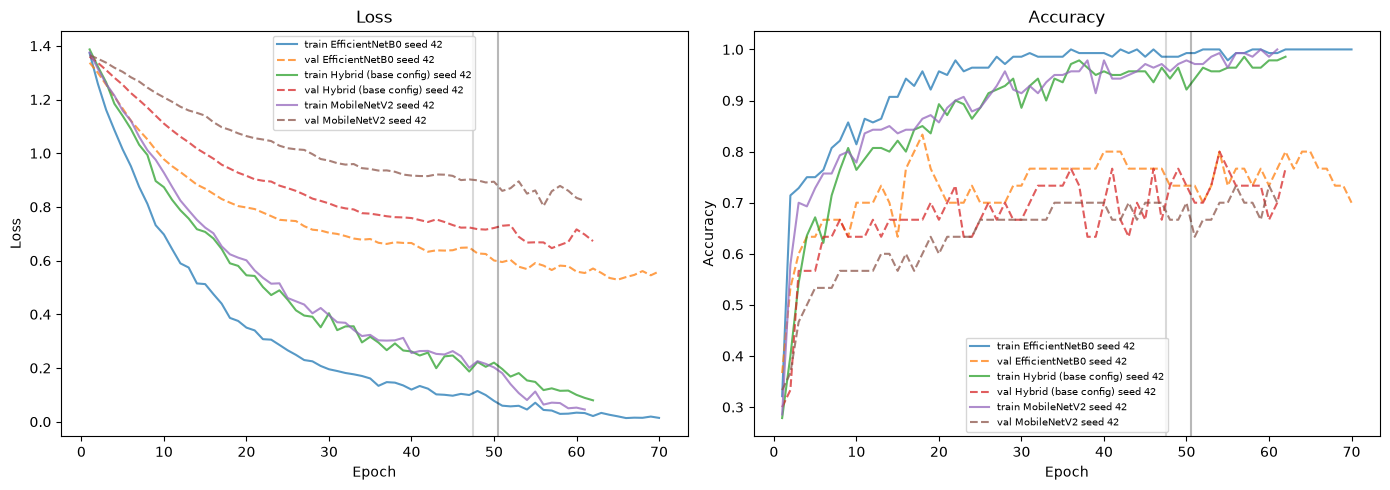

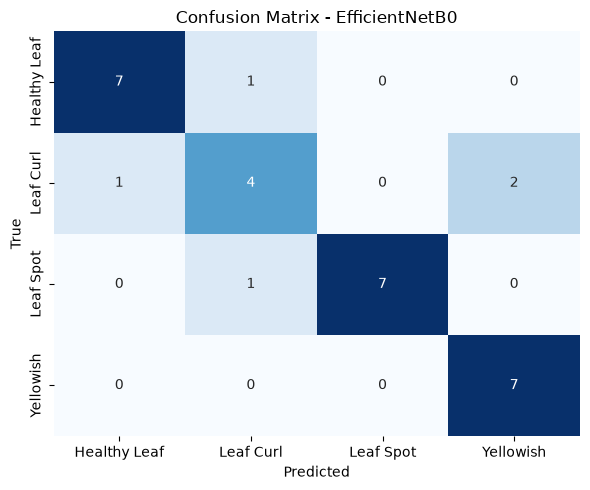

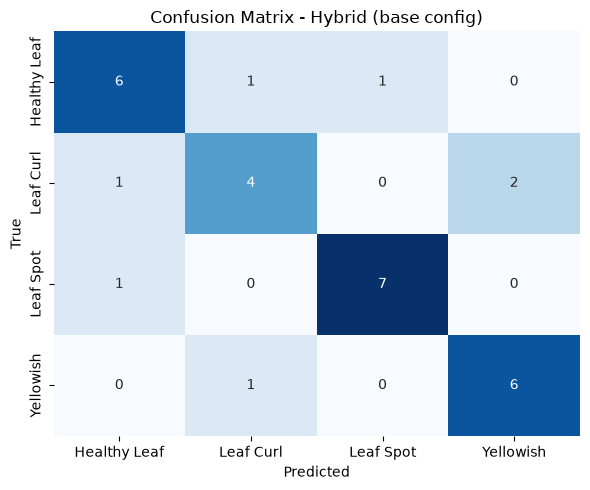

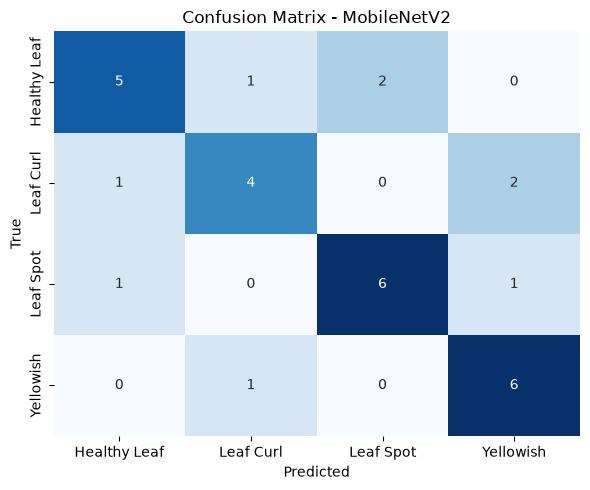

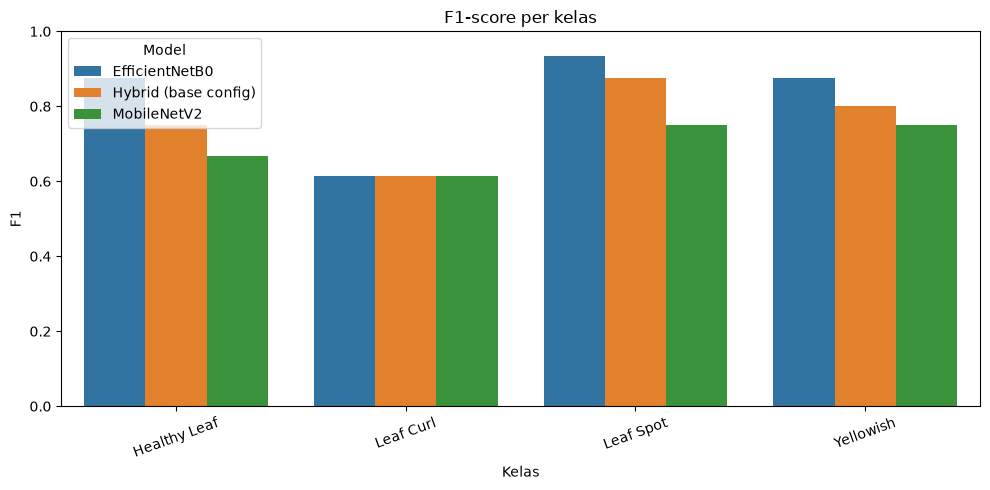

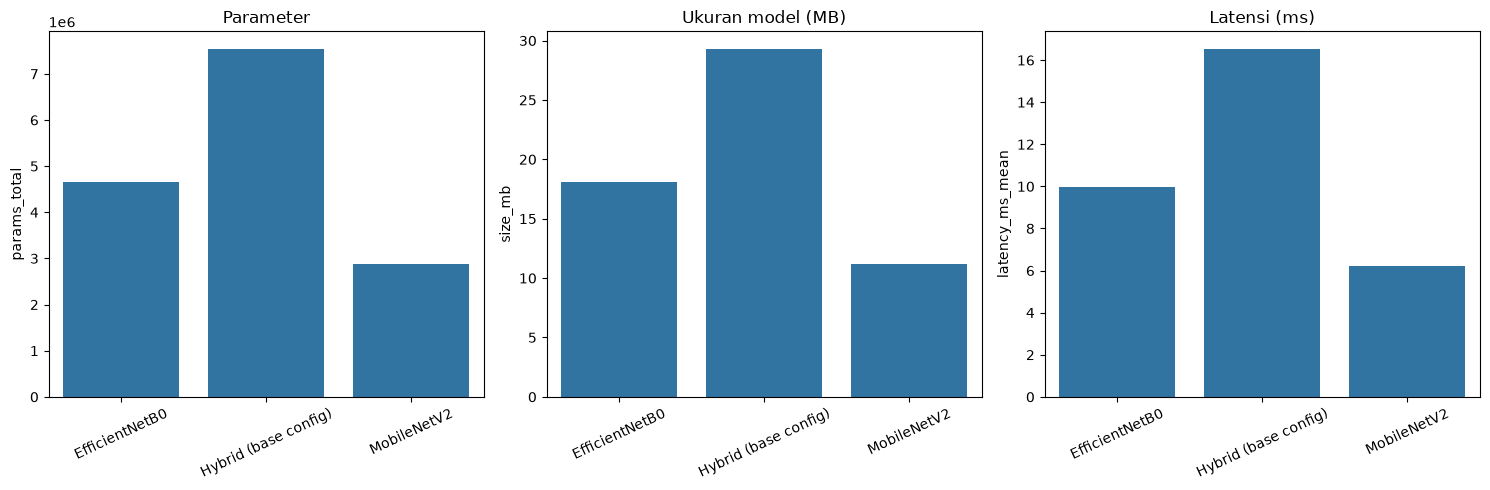

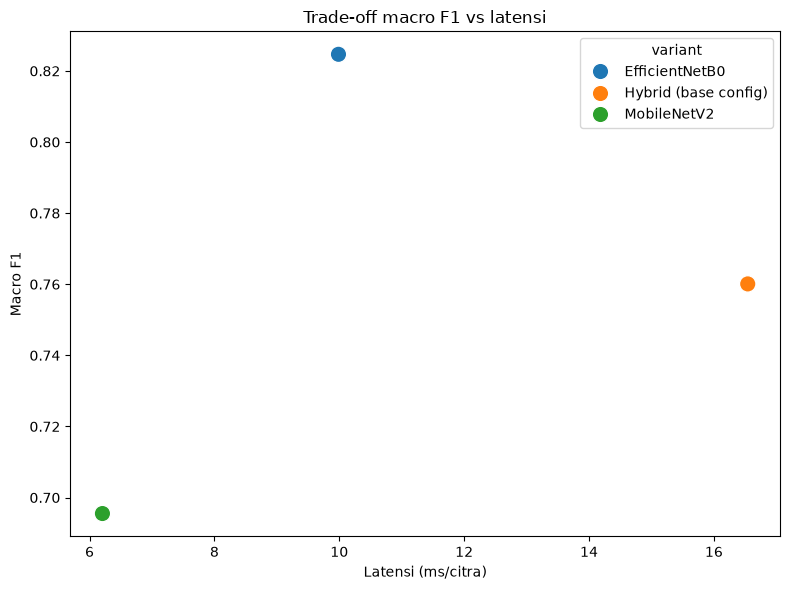

Exported files:
reports\figures\confusion_matrix_EfficientNetB0.png
reports\figures\confusion_matrix_Hybrid_base_config.png
reports\figures\confusion_matrix_MobileNetV2.png
reports\figures\efficiency.png
reports\figures\f1_per_class.png
reports\figures\preprocess_samples.png
reports\figures\tradeoff_f1_latency.png
reports\figures\training_curves.png
reports\metrics\comparison_main.csv
reports\metrics\efficiency.csv
reports\metrics\per_class.csv
reports\metrics\results_EfficientNetB0_seed42.json
reports\metrics\results_Hybrid_base_config_seed42.json
reports\metrics\results_MobileNetV2_seed42.json
reports\metrics\runs.csv


In [25]:
comparison_main.to_csv(EVAL_METRICS_DIR / "comparison_main.csv", index=False)
per_class.to_csv(EVAL_METRICS_DIR / "per_class.csv", index=False)
runs_frame[["variant", "params_total", "size_mb", "latency_ms_mean", "latency_ms_std"]].to_csv(
    EVAL_METRICS_DIR / "efficiency.csv", index=False,
)
plot_training_curves()
plot_confusion_matrices()
plot_f1_per_class()
plot_efficiency()
plot_tradeoff()
print("Exported files:")
for report_path in sorted(EVAL_REPORT_DIR.rglob("*")) :
    if report_path.is_file() :
        print(report_path)

# 13. RUN FINAL

stage=1 epoch=1/50 train_loss=1.3865 val_loss=1.3879 train_acc=0.2643 val_acc=0.3000 sec=0.76
stage=1 epoch=2/50 train_loss=1.3705 val_loss=1.3832 train_acc=0.2786 val_acc=0.3667 sec=0.55
stage=1 epoch=3/50 train_loss=1.3491 val_loss=1.3780 train_acc=0.3714 val_acc=0.3000 sec=0.57
stage=1 epoch=4/50 train_loss=1.3328 val_loss=1.3707 train_acc=0.4071 val_acc=0.3333 sec=0.58
stage=1 epoch=5/50 train_loss=1.3108 val_loss=1.3663 train_acc=0.4357 val_acc=0.3333 sec=0.62
stage=1 epoch=6/50 train_loss=1.2835 val_loss=1.3574 train_acc=0.5357 val_acc=0.3667 sec=0.61
stage=1 epoch=7/50 train_loss=1.2720 val_loss=1.3502 train_acc=0.5500 val_acc=0.4000 sec=0.63
stage=1 epoch=8/50 train_loss=1.2368 val_loss=1.3399 train_acc=0.5500 val_acc=0.4667 sec=0.65
stage=1 epoch=9/50 train_loss=1.2193 val_loss=1.3292 train_acc=0.6286 val_acc=0.5333 sec=0.64
stage=1 epoch=10/50 train_loss=1.1861 val_loss=1.3193 train_acc=0.6643 val_acc=0.6000 sec=0.69
stage=1 epoch=11/50 train_loss=1.1852 val_loss=1.3095 train

,Model,Accuracy,Precision macro,Recall macro,F1 macro,Params,Ukuran MB,Inferensi ms/citra
0,EfficientNetB0,0.8111 +/- 0.0192,0.8100 +/- 0.0172,0.8080 +/- 0.0195,0.8042 +/- 0.0177,4665472,18.0840 +/- 0.0000,10.2887 +/- 0.4164
1,Hybrid (base config),0.8111 +/- 0.0509,0.8198 +/- 0.0671,0.8080 +/- 0.0483,0.8021 +/- 0.0495,7544704,29.3145 +/- 0.0000,16.8737 +/- 0.3212
2,Hybrid (best grid),0.8222 +/- 0.0385,0.8400 +/- 0.0302,0.8214 +/- 0.0389,0.8149 +/- 0.0438,7544704,29.3145 +/- 0.0000,17.3115 +/- 0.6131
3,MobileNetV2,0.6667 +/- 0.0333,0.6739 +/- 0.0358,0.6682 +/- 0.0317,0.6588 +/- 0.0312,2881796,11.2284 +/- 0.0000,6.2130 +/- 0.3396


,Model,n primer,Acc primer,F1 primer,n sekunder,Acc sekunder,F1 sekunder
0,EfficientNetB0,13,0.8462 +/- 0.0000,0.8389 +/- 0.0000,17,0.7843 +/- 0.0340,0.7880 +/- 0.0280
1,Hybrid (base config),13,0.8462 +/- 0.0769,0.8483 +/- 0.0987,17,0.7843 +/- 0.0340,0.7880 +/- 0.0280
2,Hybrid (best grid),13,0.8462 +/- 0.0769,0.8380 +/- 0.0918,17,0.8039 +/- 0.0340,0.8065 +/- 0.0561
3,MobileNetV2,13,0.5897 +/- 0.0444,0.6190 +/- 0.0175,17,0.7255 +/- 0.0340,0.7186 +/- 0.0555


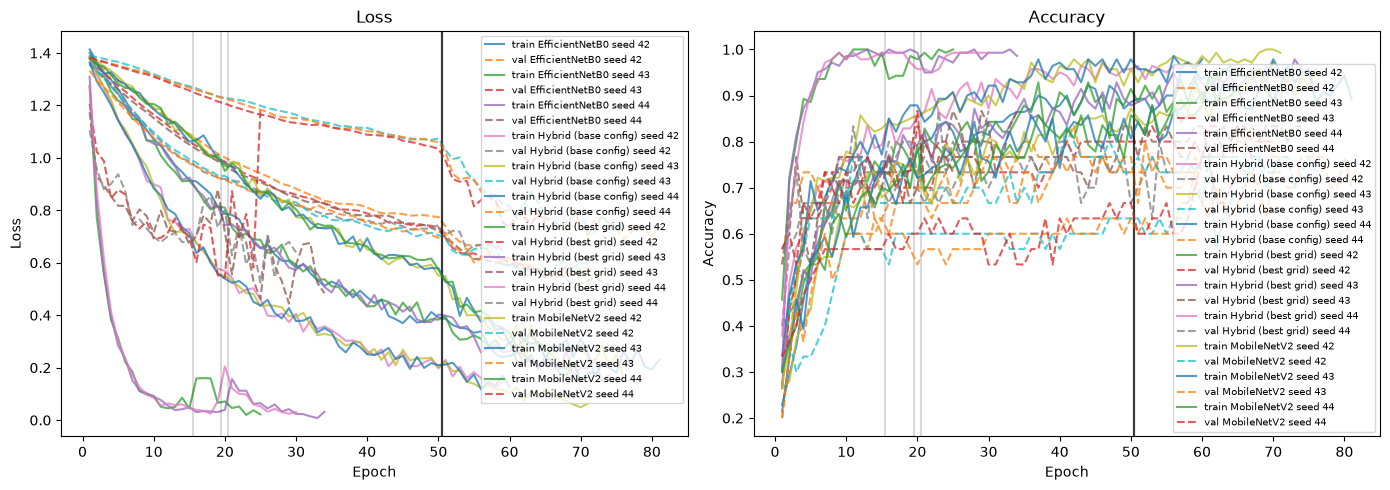

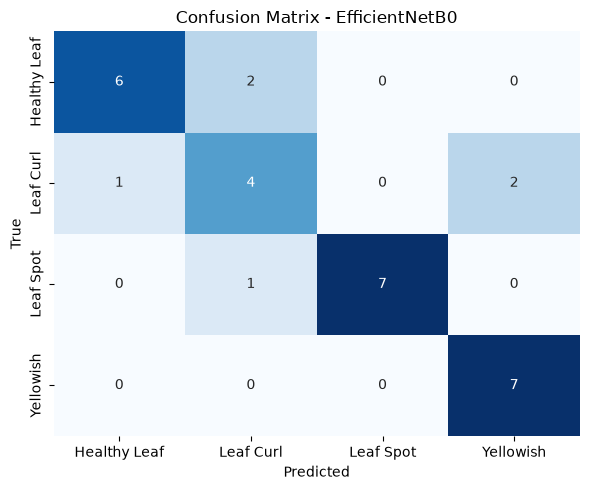

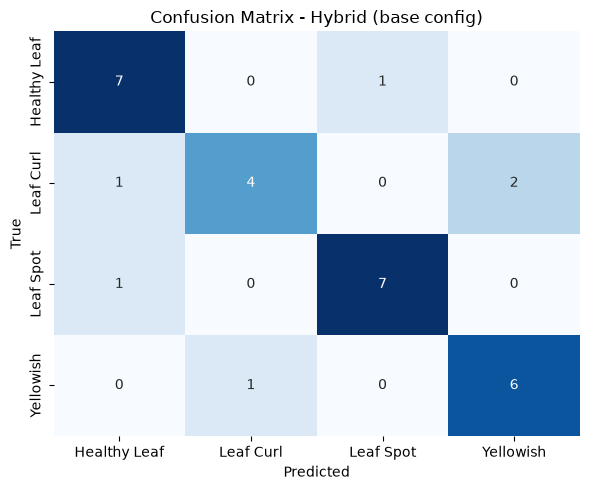

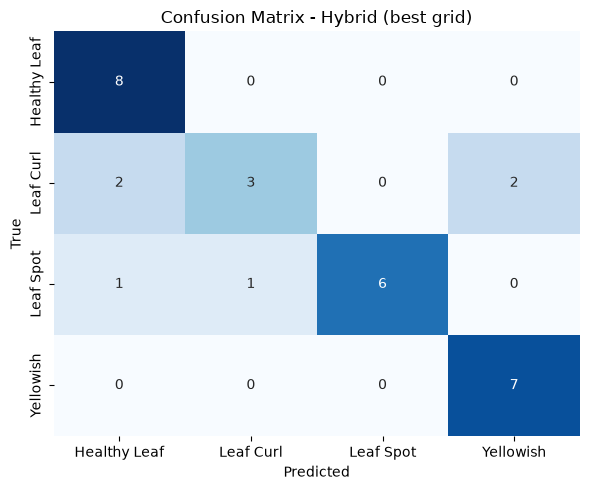

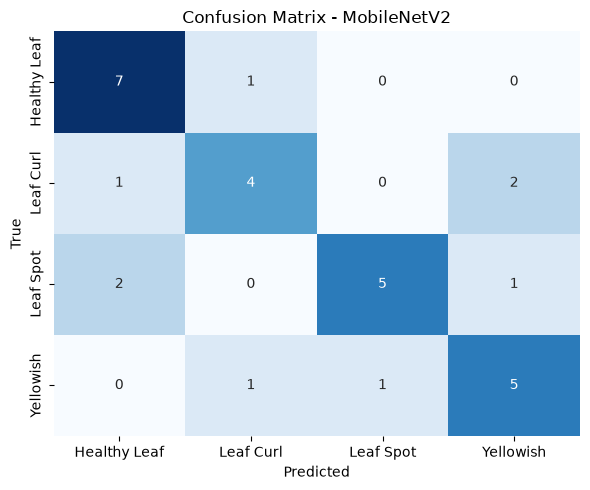

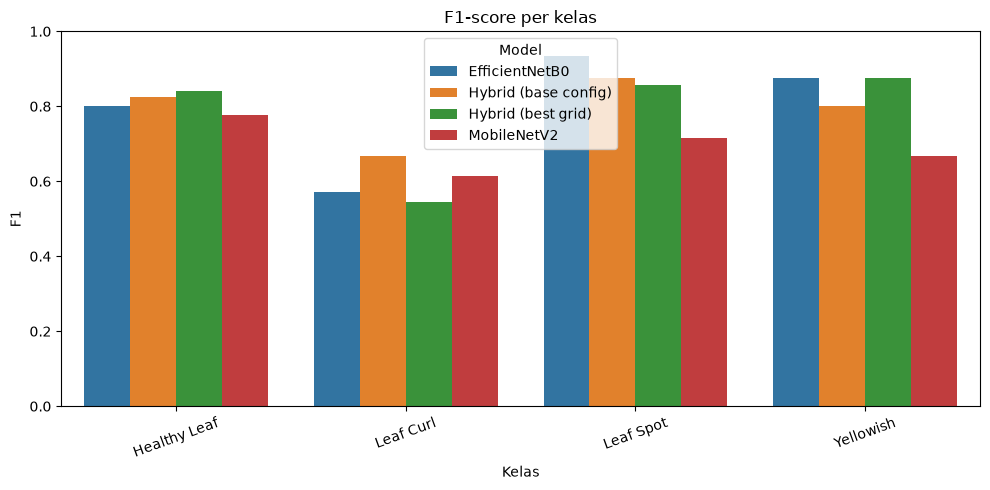

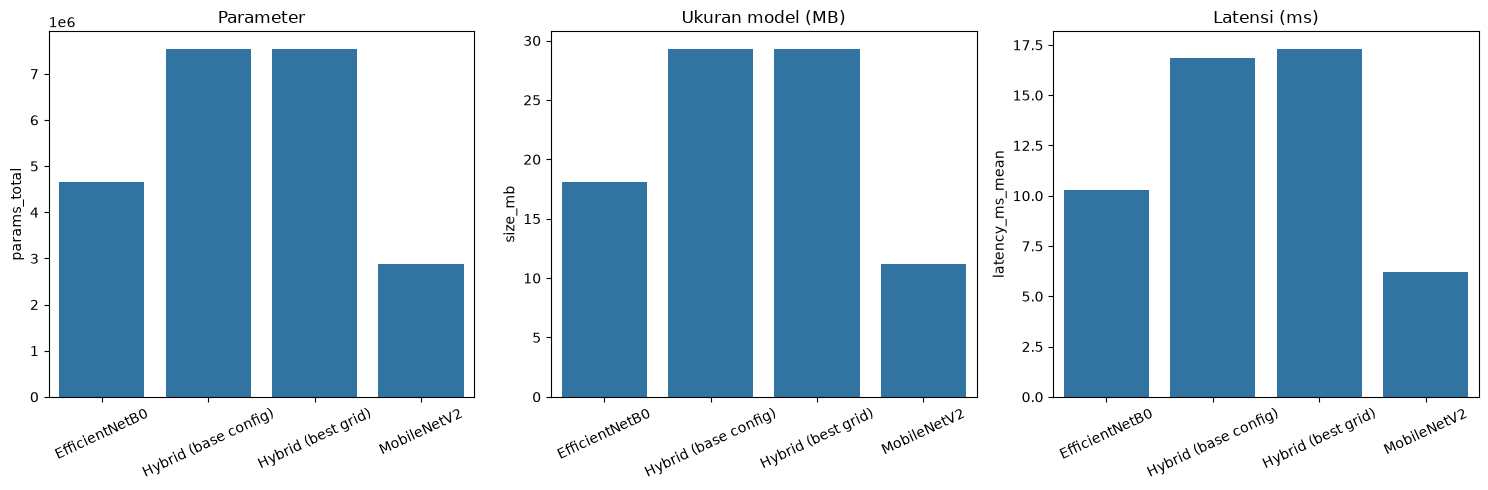

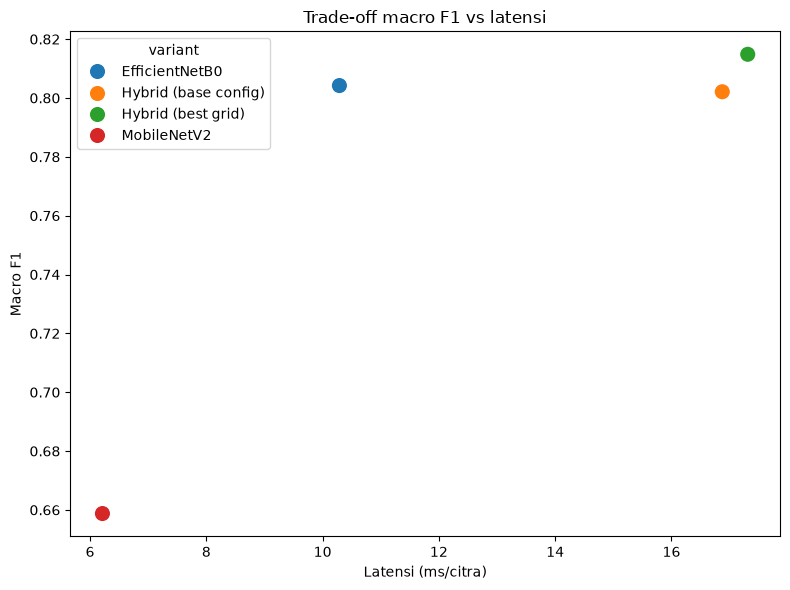

Final reports diperbarui di reports


In [18]:
final_configs = [
    ("MobileNetV2", build_mobilenet, BASE_CONFIG),
    ("EfficientNetB0", build_efficientnet, BASE_CONFIG),
    ("Hybrid (best grid)", build_hybrid, BEST_HYBRID_CFG),
    ("Hybrid (base config)", build_hybrid, BASE_CONFIG),
]
final_runs = []
for run_seed in SEEDS :
    for variant_name, builder, config in final_configs :
        run_row, run_payload = run_experiment(variant_name, builder, config, run_seed)
        final_runs.append(run_row)
        print("Final selesai :", variant_name, "seed", run_seed)

runs_frame, comparison_main, per_class, per_source = build_comparison_tables()
print("\nPerbandingan final")
display(comparison_main)
display(per_source)
comparison_main.to_csv(EVAL_METRICS_DIR / "comparison_main.csv", index=False)
per_class.to_csv(EVAL_METRICS_DIR / "per_class.csv", index=False)
runs_frame[["variant", "params_total", "size_mb", "latency_ms_mean", "latency_ms_std"]].to_csv(
    EVAL_METRICS_DIR / "efficiency.csv", index=False,
)
plot_training_curves()
plot_confusion_matrices()
plot_f1_per_class()
plot_efficiency()
plot_tradeoff()
print("Final reports diperbarui di", EVAL_REPORT_DIR)